# Pull Sentinel Data
This notebook contains the logic needed to pull the Sentinel data for each time period. We will pull the Albedo and the NDVI from each city, using the same boundary boxes as the provided TIFs.

In [14]:
import os
import json

import rasterio as rio
from rasterio.crs import CRS
import geopandas as gpd
from shapely.geometry import box, mapping

import ee


In [16]:
ee.Initialize(project='ee-zcalhounnc')

# First, let's get our data ready for the data pull.

In [9]:
# Get the list of cities.
with open('../data/data_map.json') as src:
    cities = json.load(src)['cities']

for c in cities:

    with rio.open(os.path.join('..', c['greenspace'])) as src:
        crs = src.crs.to_epsg()
        assert crs == 4326
        bounds = src.bounds
    # break

In [12]:
def tif_to_ee_geometry(tif_path: str) -> ee.Geometry:
    """Read a TIF's bounding box and return an ee.Geometry (WGS84)."""
    with rio.open(os.path.join('..', tif_path)) as src:
        bounds = src.bounds
        src_crs = src.crs
    
    # Reproject bounds to WGS84 if needed
    gdf = gpd.GeoDataFrame(
        geometry=[box(bounds.left, bounds.bottom, bounds.right, bounds.top)],
        crs=src_crs
    ).to_crs("EPSG:4326")
    
    geojson = mapping(gdf.geometry[0])
    return ee.Geometry(geojson)

def mask_s2_clouds(image: ee.Image) -> ee.Image:
    """Mask clouds using the Sentinel-2 QA60 band."""
    qa = image.select('QA60')
    cloud_bit_mask    = 1 << 10   # opaque clouds
    cirrus_bit_mask   = 1 << 11   # cirrus
    mask = (qa.bitwiseAnd(cloud_bit_mask).eq(0)
              .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0)))
    # Scale reflectance to [0, 1]
    return image.updateMask(mask).divide(10000)

In [18]:
def get_s2_collection(
    geometry: ee.Geometry,
    start_date: str,
    end_date: str,
    max_cloud_pct: float = 20.0
) -> ee.ImageCollection:
    return (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
          .filterBounds(geometry)
          .filterDate(start_date, end_date)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', max_cloud_pct))
          .map(mask_s2_clouds)
    )

In [42]:
def add_ndvi(image: ee.Image) -> ee.Image:
    """NDVI = (NIR - Red) / (NIR + Red)  →  B8, B4"""
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI').toFloat()
    return image.addBands(ndvi)

In [43]:
def add_albedo(image: ee.Image) -> ee.Image:
    """
    Broadband shortwave albedo using Bonafoni and Sekertekin (2020) coefficients
    adapted for Sentinel-2 bands.
    """
    albedo = (
        image.expression(
            '0.2266*B2 + 0.1236*B3 + 0.1573*B4 + 0.3417*B8 + 0.1170*B11 + 0.0338*B12',
            {
                'B2':  image.select('B2'),   # Blue
                'B3':  image.select('B3'),   # Green
                'B4':  image.select('B4'),   # Red
                'B8':  image.select('B8'),   # NIR
                'B11': image.select('B11'),  # SWIR 1
                'B12': image.select('B12'),  # SWIR 2
            }
        )
        .rename('Albedo')
        .clamp(0, 1)
        .toFloat()
    )
    return image.addBands(albedo)

In [44]:
def process_tifs(tif_path, start_date, end_date, name, export_to_drive=True, output_scale_m = 10):
    print(f"\n── Processing: {name}")

    # 1. Geometry
    aoi = tif_to_ee_geometry(tif_path)

    # 2. Collection → median composite
    col = get_s2_collection(aoi, start_date, end_date)
    print(f"   Images found: {col.size().getInfo()}")

    composite = col.median()

    # 3. Add bands
    composite = add_ndvi(composite)
    composite = add_albedo(composite)

    # Select only the derived bands for export
    output = composite.select(['NDVI', 'Albedo']).clip(aoi)
    # output = composite.select(['NDVI']).clip(aoi)

    if export_to_drive:
        task = ee.batch.Export.image.toDrive(
            image       = output,
            description = f'{name}_NDVI_Albedo',
            folder      = 'greenspace',
            fileNamePrefix = f'{name}_NDVI_Albedo',
            region      = aoi,
            scale       = output_scale_m,
            crs         = 'EPSG:4326',
            maxPixels   = 1e13,
            fileFormat  = 'GeoTIFF'
        )
        task.start()
        print(f"   Export task started → Drive/GEE_Exports/{name}_NDVI_Albedo.tif")

In [53]:
for c in cities[2:]:
    tif_path = c['greenspace']
    name = c['name'].split(",")[0]
    date = c['date']
    start_date = "-".join([date[:4], "05","01"])
    end_date = "-".join([date[:4], "10","01"])
    
    process_tifs(tif_path, start_date, end_date, name) 


── Processing: Brockton
   Images found: 21
   Export task started → Drive/GEE_Exports/Brockton_NDVI_Albedo.tif

── Processing: Brooklyn
   Images found: 79
   Export task started → Drive/GEE_Exports/Brooklyn_NDVI_Albedo.tif

── Processing: Cedar Rapids
   Images found: 52
   Export task started → Drive/GEE_Exports/Cedar Rapids_NDVI_Albedo.tif

── Processing: Charlotte
   Images found: 77
   Export task started → Drive/GEE_Exports/Charlotte_NDVI_Albedo.tif

── Processing: Columbus
   Images found: 5
   Export task started → Drive/GEE_Exports/Columbus_NDVI_Albedo.tif

── Processing: Durham
   Images found: 12
   Export task started → Drive/GEE_Exports/Durham_NDVI_Albedo.tif

── Processing: Jacksonville
   Images found: 7
   Export task started → Drive/GEE_Exports/Jacksonville_NDVI_Albedo.tif

── Processing: Knoxville
   Images found: 48
   Export task started → Drive/GEE_Exports/Knoxville_NDVI_Albedo.tif

── Processing: Little Rock
   Images found: 14
   Export task started → Drive/GEE

In [51]:
cities[1:]

[{'greenspace': 'data/0.6m-Greenspace_mapping/Atlanta__GA_resultv2.tif',
  'traversal': 'data/traversals/atlanta/',
  'name': 'Atlanta, GA',
  'date': '2021-09-04'},
 {'greenspace': 'data/0.6m-Greenspace_mapping/Brockton__MA_resultv2.tif',
  'traversal': 'data/traversals/brockton/',
  'name': 'Brockton, MA',
  'date': '2023-07-26'},
 {'greenspace': 'data/0.6m-Greenspace_mapping/Brooklyn__NY_resultv2.tif',
  'traversal': 'data/traversals/brooklyn/',
  'name': 'Brooklyn, NY',
  'date': '2022-07-30'},
 {'greenspace': 'data/0.6m-Greenspace_mapping/Cedar_Rapids__IA_resultv2.tif',
  'traversal': 'data/traversals/cedar_rapids/',
  'name': 'Cedar Rapids, IA',
  'date': '2023-07-22'},
 {'greenspace': 'data/0.6m-Greenspace_mapping/Charlotte__NC_resultv2.tif',
  'traversal': 'data/traversals/charlotte/',
  'name': 'Charlotte, NC',
  'date': '2024-07-14'},
 {'greenspace': 'data/0.6m-Greenspace_mapping/Columbus__OH_resultv2.tif',
  'traversal': 'data/traversals/columbus/',
  'name': 'Columbus, OH',

In [49]:
with rio.open('../data/sentinel/Asheville_NDVI_Albedo.tif') as src:
    data = src.read(2)

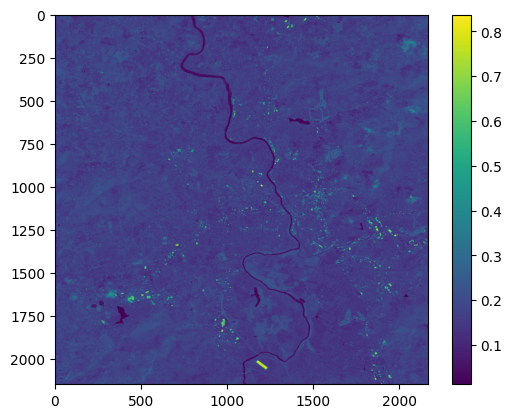

In [50]:
from matplotlib import pyplot as plt
plt.imshow(data)
plt.colorbar()